# Hybrid Theil-Sen + Year-on-Year degradation (PVDAQ system 4)

This notebook applies the two-piece hybrid degradation analysis
(`rdtools.degradation_hybrid`) to PVDAQ system 4 -- the same dataset used
in [`TrendAnalysis_example.ipynb`](TrendAnalysis_example.ipynb).

The hybrid method splits the normalized-energy time series at a
configurable boundary (default: 1 year) and fits:

- **Theil-Sen** on the year-1 window, producing a rate in %/year of the
  year-0 system capacity from a robust, non-parametric
  median-of-pairwise-slopes regression.
- **Year-on-year** on the remainder, producing a steady-state rate in
  %/year of the start-of-year-2 capacity (when `recenter_year2=True`).

This is useful when the first year of operation degrades qualitatively
differently from steady state (light-induced degradation, light-soaking,
initial stabilization). A single-rate fit averages those regimes and
hides the nonlinearity. Theil-Sen is preferred over OLS for the year-1
piece because the early-life window is short and a handful of bad days
can dominate an OLS slope.

For full data preparation and the broader `TrendAnalysis` workflow, see
[`TrendAnalysis_example.ipynb`](TrendAnalysis_example.ipynb). This
notebook focuses on the hybrid-specific configuration and outputs.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pvlib
import rdtools
%matplotlib inline


In [2]:
# Update the style of plots
import matplotlib
matplotlib.rcParams.update({'font.size': 12,
                            'figure.figsize': [4.5, 3],
                            'lines.markeredgewidth': 0,
                            'lines.markersize': 2})
# Register time series plotting in pandas > 1.0
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()


In [3]:
# Set the random seed for numpy so the bootstrap-based YoY confidence
# intervals are reproducible across runs.
np.random.seed(0)


## 1. Import and prepare data

Loads PVDAQ system 4 from the cached CSV and assembles the metadata dict
needed by `TrendAnalysis`. The data preparation here mirrors
`TrendAnalysis_example.ipynb`, minus the synthetic soiling multiplication
(we run the hybrid fit on the AC power directly so the result isn't
distorted by the synthetic signal).


In [4]:
# Import the example data
file_url = ('https://github.com/NatLabRockies/rdtools/releases/download/3.0.0/'
            'pvdaq_system_4_2010-2016_subset_soil_signal.csv')
cache_file = 'PVDAQ_system_4_2010-2016_subset_soilsignal.pickle'

try:
    df = pd.read_pickle(cache_file)
except FileNotFoundError:
    df = pd.read_csv(file_url, index_col=0, parse_dates=True)
    df.to_pickle(cache_file)


In [5]:
df = df.rename(columns={
    'ac_power': 'power_ac',
    'wind_speed': 'wind_speed',
    'ambient_temp': 'Tamb',
    'poa_irradiance': 'poa',
})

# Specify the Metadata
meta = {"latitude": 39.7406,
        "longitude": -105.1774,
        "timezone": 'Etc/GMT+7',
        "gamma_pdc": -0.0034,  # 1/K, modern silicon PV modules
        "azimuth": 180,
        "tilt": 40,
        "power_dc_rated": 1000.0,
        "temp_model_params": 'open_rack_glass_polymer'}

df.index = df.index.tz_localize(meta['timezone'])

# Some missing data, so infer the frequency from the first few points.
freq = pd.infer_freq(df.index[:10])


## 2. Configure `TrendAnalysis`

Same setup as `TrendAnalysis_example.ipynb`. We pass `power_ac` directly
(no synthetic soiling) so the degradation signal is as clean as the
dataset allows.


In [6]:
ta = rdtools.TrendAnalysis(df['power_ac'], df['poa'],
                           temperature_ambient=df['Tamb'],
                           gamma_pdc=meta['gamma_pdc'],
                           interp_freq=freq,
                           windspeed=df['wind_speed'],
                           power_dc_rated=meta['power_dc_rated'],
                           temperature_model=meta['temp_model_params'])


## 3. Run the hybrid analysis

We run year-on-year and hybrid in a single call so we can compare them on
the same preprocessing and filtering pipeline. The analyses are
independent and both results land under `ta.results['sensor']`.


In [7]:
ta.sensor_analysis(
    analyses=['yoy_degradation', 'hybrid_degradation'],
    hybrid_kwargs={'year1_method': 'theil_sen'},
)


The hybrid result is a dict with explicit per-piece rates plus the full
`(Rd_pct, Rd_CI, calc_info)` tuples from each underlying call -- Theil-Sen
for year 1, YoY for years 2+ -- under `calc_info['year1']` and
`calc_info['years2plus']`.


In [8]:
yoy_results    = ta.results['sensor']['yoy_degradation']
hybrid_results = ta.results['sensor']['hybrid_degradation']

print('YoY whole-series:')
print(f"  Rd     = {yoy_results['p50_rd']:+.3f} %/yr   "
      f"68% CI = [{yoy_results['rd_confidence_interval'][0]:+.3f}, "
      f"{yoy_results['rd_confidence_interval'][1]:+.3f}]")

print('\nHybrid (year 1 Theil-Sen + years 2+ YoY):')
ci1 = hybrid_results['calc_info']['year1'][1]
ci2 = hybrid_results['calc_info']['years2plus'][1]
print(f"  year 1   Rd = {hybrid_results['rd_pct_year1']:+.3f} %/yr   "
      f"68% CI = [{ci1[0]:+.3f}, {ci1[1]:+.3f}]")
print(f"  years 2+ Rd = {hybrid_results['rd_pct_years2plus']:+.3f} %/yr   "
      f"68% CI = [{ci2[0]:+.3f}, {ci2[1]:+.3f}]")
print(f"  split at:     {hybrid_results['calc_info']['split_date']:%Y-%m-%d}")


YoY whole-series:
  Rd     = -0.456 %/yr   68% CI = [-0.531, -0.418]

Hybrid (year 1 Theil-Sen + years 2+ YoY):
  year 1   Rd = +0.351 %/yr   68% CI = [-0.045, +0.711]
  years 2+ Rd = -0.422 %/yr   68% CI = [-0.473, -0.378]
  split at:     2011-02-25


## 4. Plot the hybrid summary

`TrendAnalysis.plot_hybrid_degradation_summary` returns a two-panel
figure:

- **Left:** scatter of the daily aggregated normalized performance with
  the year-1 OLS fit line, the years-2+ YoY rate line, and a vertical
  marker at the split date.
- **Right:** histogram of the years-2+ YoY slopes, the dashed line at
  the median rate, and a text annotation with both rates and their 68%
  confidence intervals.


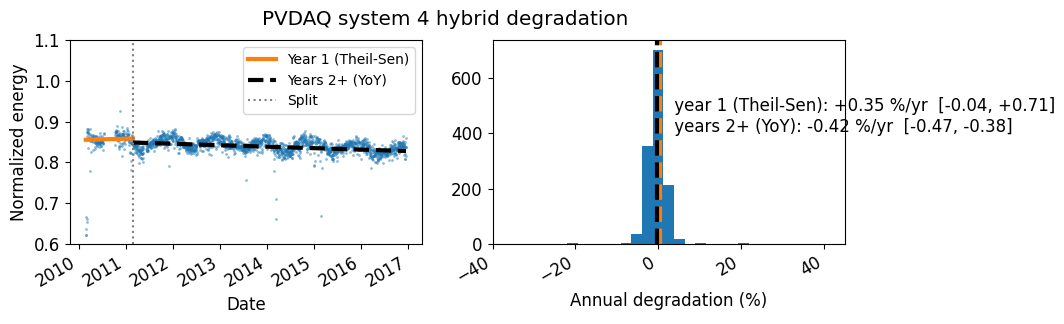

In [9]:
fig = ta.plot_hybrid_degradation_summary(
    'sensor',
    summary_title='PVDAQ system 4 hybrid degradation',
    scatter_ymin=0.6, scatter_ymax=1.1,
    hist_xmin=-40, hist_xmax=45,
)
plt.show()


## 5. Fourier-OLS year-1 method

The built-in `'fourier_ols'` choice
([`degradation_fourier_ols`](../api.html#rdtools.degradation_fourier_ols))
is a two-stage method designed for short year-1 windows where the linear
trend and seasonal regressors are not orthogonal on a single annual
cycle:

1. **Stage 1** (always OLS): fit a linear trend plus
   `harmonics` pairs of sine/cosine regressors on the full multi-year
   series to constrain the seasonal pattern from every cycle the data
   contains. Year 1 is included by default; pass
   `skip_year1_in_seasonal_fit=True` to exclude it when an unusual
   year-1 trend (LID, light-soaking, initial stabilization) might
   otherwise bias the seasonal coefficients.
2. **Stage 2**: subtract that seasonal pattern from the year-1 slice
   and fit the slope of the deseasonalized residual. The `slope_method`
   kwarg picks the stage-2 regression:
   - `'ols'` (default) — parametric uncertainty via Monte-Carlo on
     the OLS covariance.
   - `'theil_sen'` — robust median-of-pairwise-slopes fit
     ([`degradation_theil_sen`](../api.html#rdtools.degradation_theil_sen))
     with a rank-based CI, resistant to bad days in the year-1 window.

Stage-1 OLS stays OLS because seasonality is fit on thousands of points
across many cycles where individual outliers wash out; stage 2 is the
short window where robustness matters. The cell below runs both
stage-2 choices on the same preprocessing and the figure that follows
shows the Theil-Sen result.


In [10]:
# Run hybrid with fourier_ols, comparing the two stage-2 slope choices.
# Each call only recomputes the degradation step; preprocessing is reused.
fourier_results = {}
for slope_method in ('ols', 'theil_sen'):
    ta.sensor_analysis(
        analyses=['hybrid_degradation'],
        hybrid_kwargs={'year1_method': 'fourier_ols',
                       'year1_kwargs': {'slope_method': slope_method}},
    )
    fourier_results[slope_method] = ta.results['sensor']['hybrid_degradation']

print("Fourier-OLS year-1 method (stage-2 slope comparison)")
header = f"  {'slope_method':>12}  {'year-1':>8}  {'years 2+':>9}  {'year-1 68% CI':>22}"
print(header)
print("  " + "-" * (len(header) - 2))
for slope_method, r in fourier_results.items():
    ci1 = r['calc_info']['year1'][1]
    print(f"  {slope_method:>12}  "
          f"{r['rd_pct_year1']:+8.3f}  "
          f"{r['rd_pct_years2plus']:+9.3f}  "
          f"[{ci1[0]:+6.3f}, {ci1[1]:+6.3f}]")


Fourier-OLS year-1 method (stage-2 slope comparison)
  slope_method    year-1   years 2+           year-1 68% CI
  ---------------------------------------------------------
           ols    +2.276     -0.422  [+1.241, +3.313]
     theil_sen    -1.259     -0.422  [-1.598, -0.900]


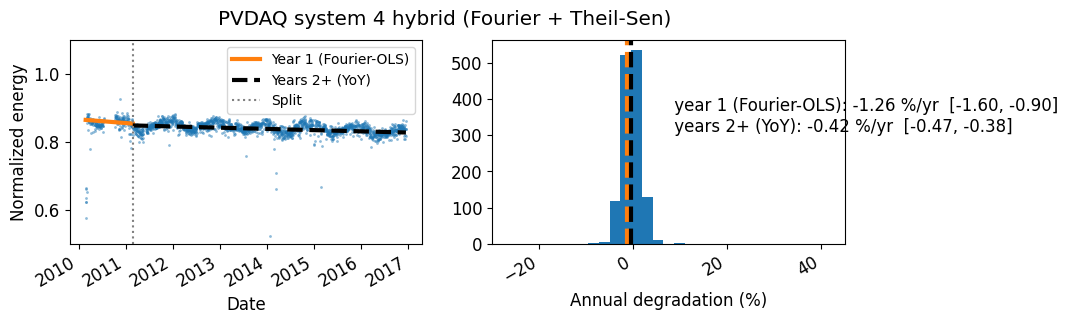

In [11]:
# The plot method reads whichever hybrid result is currently stored
# under ta.results['sensor']['hybrid_degradation'], so the figure below
# reflects the Theil-Sen Fourier-OLS run from the cell above.
fig = ta.plot_hybrid_degradation_summary(
    'sensor',
    summary_title='PVDAQ system 4 hybrid (Fourier + Theil-Sen)',
    scatter_ymin=0.5, scatter_ymax=1.1,
    hist_xmin=-30, hist_xmax=45,
)
plt.show()
